# Reducción 2D: dos momentos y caudal único

Calbuco, conducto cilíndrico. En cada altura, con `M` radios libres:

- masa del fundido en cada radio
- masa del gas una sola vez, `Q = const` (integral del flujo total)
- momento del fundido en cada radio
- momento del gas en cada radio
- `N` y `ξ` en cada radio

`P = P(z)`. En la pared `u_m = u_g = 0`. `ρ_m = ρ_m(P)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from RIconduit2D_Q import marchar

sal = marchar(vinicial=1.0, n_r=10, dz=200.0)
print("pasos", sal["n_pasos"], "|", sal["mensaje"])
print("z inicial, final [m]", sal["z"][0], sal["z"][-1])
print("P inicial, final [MPa]", sal["P"][0] / 1e6, sal["P"][-1] / 1e6)
print("Q [kg/s]", sal["Q_objetivo"])
print("error relativo máximo de Q", np.max(np.abs(sal["Q"] - sal["Q_objetivo"]) / sal["Q_objetivo"]))
print("φ máximo", sal["phi"].max())
print("ρ_m en la base [kg/m³]", sal["rho_m_base"])


pasos 39 | boca
z inicial, final [m] -7000.0 0.0
P inicial, final [MPa] 183.542 13.439764406747111
Q [kg/s] 1956559.4813050334
error relativo máximo de Q 3.570001002452079e-16
φ máximo 0.04300842311161855
ρ_m en la base [kg/m³] 2463.1919048567393


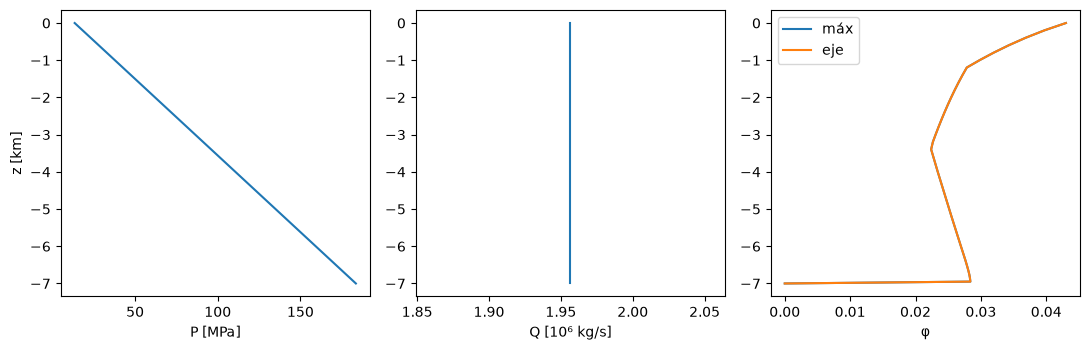

In [2]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.6))
ejes[0].plot(sal["P"] / 1e6, sal["z"] / 1e3)
ejes[0].set_xlabel("P [MPa]")
ejes[0].set_ylabel("z [km]")
ejes[1].plot(sal["Q"] / 1e6, sal["z"] / 1e3)
ejes[1].set_xlabel("Q [10⁶ kg/s]")
ejes[2].plot(sal["phi"].max(axis=1), sal["z"] / 1e3, label="máx")
ejes[2].plot(sal["phi"][:, 0], sal["z"] / 1e3, label="eje")
ejes[2].set_xlabel("φ")
ejes[2].legend()
fig.tight_layout()
fig.savefig("/opt/cursor/artifacts/q2d-columnas.png", dpi=120)
plt.show()


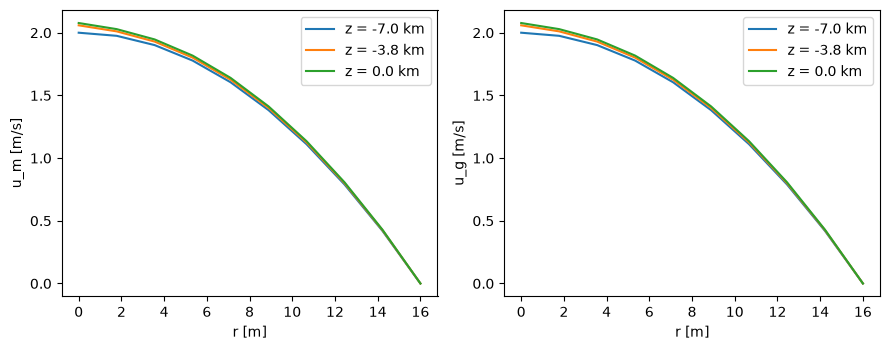

In [3]:
r = sal["r"]
niveles = [0, len(sal["z"]) // 2, -1]
fig, ejes = plt.subplots(1, 2, figsize=(9, 3.6))
for j in niveles:
    etiqueta = f"z = {sal['z'][j] / 1e3:.1f} km"
    ejes[0].plot(r, sal["um"][j], label=etiqueta)
    ejes[1].plot(r, sal["ug"][j], label=etiqueta)
ejes[0].set_xlabel("r [m]")
ejes[0].set_ylabel("u_m [m/s]")
ejes[1].set_xlabel("r [m]")
ejes[1].set_ylabel("u_g [m/s]")
ejes[0].legend()
ejes[1].legend()
fig.tight_layout()
fig.savefig("/opt/cursor/artifacts/q2d-perfiles.png", dpi=120)
plt.show()
